In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance
import time
import unittest

DATA_PATH = "Lab_Session_Data.xlsx"
df = pd.read_excel(DATA_PATH, sheet_name="marketing_campaign")
df = df.dropna(subset=["Income"]).reset_index(drop=True)
print("Data shape:", df.shape)
df.head()

Data shape: (2216, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09 00:00:00,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03 00:00:00,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02 00:00:00,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [13]:
# A1 - repeat of Lab 03 a2/a3 (categorical encoding), regenerated with AI tools
# GenAI tool used: Claude (Anthropic)
def label_encode_column(column: pd.Series):
    unique_vals = sorted(column.dropna().unique())
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    encoded_column = column.map(mapping)
    return encoded_column, mapping


def one_hot_encode_column(column: pd.Series) -> pd.DataFrame:
    return pd.get_dummies(column, prefix=column.name).astype(int)


def apply_label_encoding(data: pd.DataFrame, columns: list):
    data = data.copy()
    mappings = {}
    for col in columns:
        encoded_col, mapping = label_encode_column(data[col])
        data[f"{col}_encoded"] = encoded_col
        mappings[col] = mapping
    return data, mappings


def apply_one_hot_encoding(data: pd.DataFrame, columns: list) -> pd.DataFrame:
    data = data.copy()
    encoded_parts = [data.drop(columns=columns)]
    for col in columns:
        encoded_parts.append(one_hot_encode_column(data[col]))
    return pd.concat(encoded_parts, axis=1)


cat_cols = ["Education", "Marital_Status"]
label_df, mappings = apply_label_encoding(df, cat_cols)
onehot_df = apply_one_hot_encoding(df, cat_cols)

print("Original shape:", df.shape)
print("Mappings:", mappings)
print("Label-encoded shape:", label_df.shape)
print("One-hot encoded shape:", onehot_df.shape)

Original shape: (2216, 29)
Mappings: {'Education': {'2n Cycle': 0, 'Basic': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}, 'Marital_Status': {'Absurd': 0, 'Alone': 1, 'Divorced': 2, 'Married': 3, 'Single': 4, 'Together': 5, 'Widow': 6, 'YOLO': 7}}
Label-encoded shape: (2216, 31)
One-hot encoded shape: (2216, 40)


    p  Own Function  SciPy Function      Abs Diff
0   1  13425.000000    13425.000000  0.000000e+00
1   2  11825.003721    11825.003721  0.000000e+00
2   3  11794.975787    11794.975787  0.000000e+00
3   4  11794.036214    11794.036214  0.000000e+00
4   5  11794.001454    11794.001454  0.000000e+00
5   6  11794.000061    11794.000061  1.818989e-12
6   7  11794.000003    11794.000000  2.937490e-06
7   8  11794.000000    11794.000000  1.189910e-07
8   9  11794.000000    11794.000000  5.415131e-09
9  10  11794.000000    11794.000000  2.510205e-10


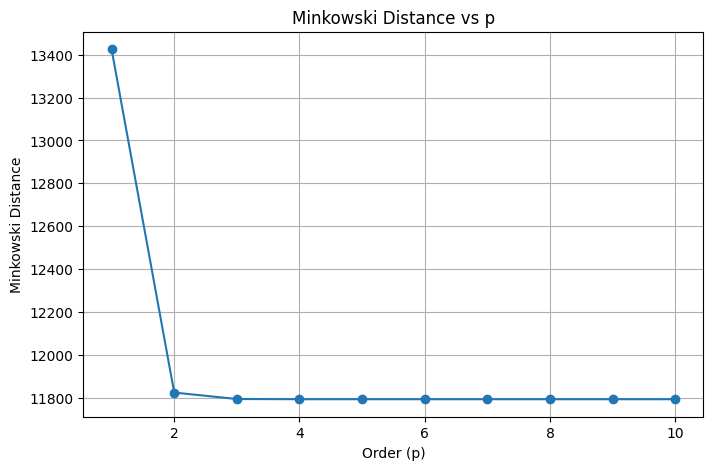

In [14]:
# A1 - repeat of Lab 03 a4/a5/a6 (Minkowski distance, own vs SciPy), regenerated with AI tools
# GenAI tool used: Claude (Anthropic)
def minkowski_distance(vector1, vector2, p):
    v1 = np.array(vector1, dtype=float)
    v2 = np.array(vector2, dtype=float)
    return np.sum(np.abs(v1 - v2) ** p) ** (1 / p)


numeric_cols = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
                 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
                 'NumStorePurchases', 'NumWebVisitsMonth']

vector_A = df.loc[0, numeric_cols].values
vector_B = df.loc[1, numeric_cols].values

p_values = list(range(1, 11))
own_distances = [minkowski_distance(vector_A, vector_B, p) for p in p_values]
scipy_distances = [distance.minkowski(vector_A, vector_B, p) for p in p_values]

comparison_df = pd.DataFrame({
    "p": p_values,
    "Own Function": own_distances,
    "SciPy Function": scipy_distances,
    "Abs Diff": np.abs(np.array(own_distances) - np.array(scipy_distances))
})
print(comparison_df)

plt.figure(figsize=(8, 5))
plt.plot(p_values, own_distances, marker='o')
plt.xlabel('Order (p)')
plt.ylabel('Minkowski Distance')
plt.title('Minkowski Distance vs p')
plt.grid(True)
plt.show()

In [15]:
# A1 - repeat of Lab 03 a7 (dot product, Euclidean norm), regenerated with AI tools
# GenAI tool used: Claude (Anthropic)
def dot_product(vector1, vector2):
    v1 = np.array(vector1, dtype=float)
    v2 = np.array(vector2, dtype=float)
    return np.sum(v1 * v2)


def euclidean_norm(vector):
    v = np.array(vector, dtype=float)
    return np.sqrt(np.sum(v ** 2))


own_dot = dot_product(vector_A, vector_B)
own_norm_A = euclidean_norm(vector_A)
numpy_dot = np.dot(vector_A.astype(float), vector_B.astype(float))
numpy_norm_A = np.linalg.norm(vector_A.astype(float))

print("Own dot product:", own_dot, "| NumPy:", numpy_dot)
print("Own norm A:", own_norm_A, "| NumPy:", numpy_norm_A)

Own dot product: 2694361052.0 | NumPy: 2694361052.0
Own norm A: 58144.51653423563 | NumPy: 58144.51653423563


In [16]:
# A1 - repeat of Lab 03 a8/a9 (mean, variance, std, own vs NumPy), regenerated with AI tools
# GenAI tool used: Claude (Anthropic)
def calculate_mean(data_matrix):
    return np.sum(data_matrix, axis=0) / data_matrix.shape[0]


def calculate_variance(data_matrix):
    mean_vector = calculate_mean(data_matrix)
    return np.sum((data_matrix - mean_vector) ** 2, axis=0) / data_matrix.shape[0]


def calculate_std(data_matrix):
    return np.sqrt(calculate_variance(data_matrix))


feature_matrix = df[numeric_cols].values
own_mean = calculate_mean(feature_matrix)
own_variance = calculate_variance(feature_matrix)
own_std = calculate_std(feature_matrix)

numpy_mean = feature_matrix.mean(axis=0)
numpy_std = feature_matrix.std(axis=0)

print("Max diff (mean):", np.abs(own_mean - numpy_mean).max())
print("Max diff (std):", np.abs(own_std - numpy_std).max())

Max diff (mean): 0.0
Max diff (std): 0.0


Histogram counts: [1654  554    7    0    0    0    0    0    0    1]
Income mean: 52247.25135379061 | Income variance: 633397830.1872725


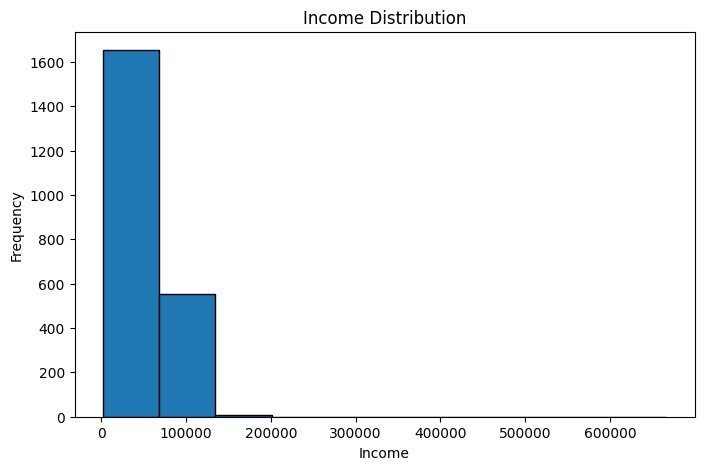

In [17]:
# A1 - repeat of Lab 03 a10 (histogram of Income), regenerated with AI tools
# GenAI tool used: Claude (Anthropic)
selected_feature = df['Income'].dropna().values
hist_counts, bin_edges = np.histogram(selected_feature, bins=10)
feature_mean = calculate_mean(selected_feature.reshape(-1, 1))[0]
feature_variance = calculate_variance(selected_feature.reshape(-1, 1))[0]

print("Histogram counts:", hist_counts)
print("Income mean:", feature_mean, "| Income variance:", feature_variance)

plt.figure(figsize=(8, 5))
plt.hist(selected_feature, bins=10, edgecolor="black")
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

In [21]:
# A1 - repeat of Lab 03 a11 (K-Means), this is my OWN Lab 03 implementation kept as baseline
# GenAI tool used: none (own code, needed as the "own" side of A3 comparison)
# K-Means function
def kmeans_own(data, k, iterations=100, seed=42):
    rng = np.random.default_rng(seed)
    centroids = data[:k].copy()
    labels = np.zeros(data.shape[0], dtype=int)

    for _ in range(iterations):
        dists = np.linalg.norm(data[:, None] - centroids, axis=2)
        labels = np.argmin(dists, axis=1)

        new_centroids = np.array([
            data[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
            for i in range(k)
        ])

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

# Example dataset
data = np.array([
    [1, 2],
    [1, 3],
    [2, 2],
    [8, 8],
    [9, 8],
    [8, 9]
])

# Call the function
labels, centroids = kmeans_own(data, k=2)

# Print outputs
print('Cluster Labels:')
print(labels)

print('\nFinal Centroids:')
print(centroids)

Cluster Labels:
[0 0 0 1 1 1]

Final Centroids:
[[1.33333333 2.33333333]
 [8.33333333 8.33333333]]
